# 1. Importación de librerías requeridas

In [180]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from scipy.stats import uniform, randint

# 2. Carga de datos y revisión del dataset

In [181]:
data = pd.read_csv("data/wine_quality.csv")
data.head()

,Unnamed: 0,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Se eliminará la columna que enumera las filas ya que no es necesaria para el modelo.

In [182]:
data.drop(columns='Unnamed: 0', inplace=True)

Se usa el método info() para visualizar el tipo de datos de cada columna

In [183]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


## 2.1 Distribución de variables

Se utiliza el método describe() para verificar la distribución numérica de los datos de cada columna.

In [184]:
data.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


Se evidencia un dispersión grande en las variables free_sulfur_dioxide y total_sulfur_dioxide, por ende en el pipeline de búsqueda de hiperparámetros se incluirá la escalación de las variables y se tenga una distribución normal que no afecte los modelos basados en distancias y descenso de gradiente que se vayan a utilizar.

## 2.2 Balance de variables

Se visualizan las diferentes categorías para ver qué tan desbalanceadas están las clases

In [185]:
data["quality"].value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

Debido a que se utilizará XGBoost para la clasificación, éste espera etiquetas que comiencen desde 0 por ende se modificará la numeración de las etiquetas.

In [186]:
data["quality"] = data["quality"] - data["quality"].min()
data["quality"].value_counts()

quality
3    2836
2    2138
4    1079
1     216
5     193
0      30
6       5
Name: count, dtype: int64

Se evidencia que hay clases con mayor cantidad de elementos que otras clases, es un dataset desbalanceado, lo que se deberá tener en cuenta al momento de hacer el entrenamiento del modelo. Se instancia un objeto `SMOTE` para realizar el oversampling de las clases minoritarias, se utilizará `sampling_strategy="auto"` para igualar los datos de las clases minoritarias y obtener un dataset con el mismo número de filas para todas las clases. Se utiliza el parámetro `k_neighbors=3` porque la clase 9 tiene menos datos de los requeridos para hacer le oversampling por default que requiere K=5.

In [187]:
smote = SMOTE(sampling_strategy="auto", random_state=52, k_neighbors=3)

## 2.3 Verificación de filas duplicadas

In [188]:
data.duplicated().sum()

1179

Se eliminarán las filas duplicadas para evitar overfitting de los modelos.

In [189]:
data = data.drop_duplicates()

In [190]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5318 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         5318 non-null   float64
 1   volatile_acidity      5318 non-null   float64
 2   citric_acid           5318 non-null   float64
 3   residual_sugar        5318 non-null   float64
 4   chlorides             5318 non-null   float64
 5   free_sulfur_dioxide   5318 non-null   float64
 6   total_sulfur_dioxide  5318 non-null   float64
 7   density               5318 non-null   float64
 8   pH                    5318 non-null   float64
 9   sulphates             5318 non-null   float64
 10  alcohol               5318 non-null   float64
 11  quality               5318 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 540.1 KB


In [191]:
data["quality"].value_counts()

quality
3    2323
2    1751
4     855
1     206
5     148
0      30
6       5
Name: count, dtype: int64

## 2.4. División del dataset en entrenamiento y test

Se utlizará el parámetro `stratify=y` para asegurar que el dataset de test contenga la misma distribución de clases del dataset original, sin dejar ninguna clase por fuera.

In [192]:
X = data.drop('quality', axis=1)
y = data['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=52, stratify=y)

In [193]:
y_test.value_counts()

quality
3    465
2    350
4    171
1     41
5     30
0      6
6      1
Name: count, dtype: int64

Se realiza el balanceo sólo para las variables de entrenamiento para evitar agregar data irreal al dataset de test que pueda afectar la evaluación de los modelos, esto permite usar datos reales para el dataset de test.

quality
2    1858
3    1858
5    1858
4    1858
1    1858
6    1858
0    1858
Name: count, dtype: int64


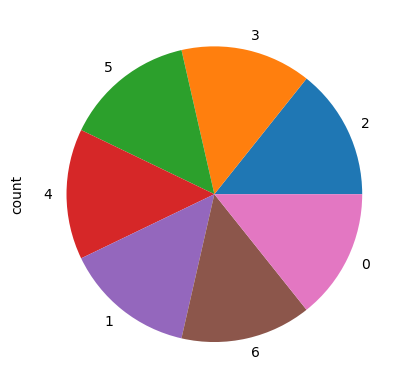

In [194]:
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
y_train_over.value_counts().plot(kind='pie')
print(y_train_over.value_counts())

In [195]:
X_train_over.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,13006.000000,13006.000000,13006.000000,13006.000000,13006.000000,13006.000000,13006.000000,13006.000000,13006.000000,13006.000000,13006.000000
mean,7.318537,0.377310,0.316450,4.727821,0.055035,30.504449,112.194788,0.994007,3.246601,0.512902,10.905651
std,1.183466,0.207237,0.137614,3.810198,0.038551,23.453421,60.178173,0.002900,0.148245,0.132363,1.261826
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.740000,0.220000,8.000000
25%,6.600000,0.250000,0.250024,2.000000,0.033838,15.427677,73.215157,0.991466,3.150000,0.426213,9.832279
50%,7.111463,0.307414,0.324489,3.218601,0.043674,28.365776,117.080946,0.993970,3.249511,0.483901,10.800000
75%,7.869253,0.430342,0.399958,6.495000,0.064525,39.160577,143.906365,0.996290,3.338383,0.579955,12.000000
max,15.900000,1.580000,1.000000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


# 3. Creación de funciones para el Pipeline

## 3.1. Definición de pipelines para cada modelo

Se utilizarán tres pipelines para tres modelos de clasificación (XGBoost, SVM y Regresión logística), se utilizan estos tres algoritmos ya que tienen un buen desempeño para clasificaciones multiclase donde el límite de separación es no lineal. Las pipelines contendrán los siguientes pasos:

1. Escalación por medio de la clase `StandardScaler()` de las variables para SVM y regresión logística ya que el desempeño de éstos se ve afectado por la distancia entre los datos ya que usan distancias y descenso de gradiente como método de optimización. Para XGBoost no es necesario el escalamiento pues es un modelo basado en ârboles de decisión, los cuales trabajan adecuadamente con datos sin escalar.
2. Aplicación del modelo supervisado para la clasificación (XGBoost, SVM y Regresión logística).

    2.1 `XGBoost`: se utilizará como métrica de evaluación `mlogloss` ya que es una métrica utilizada comunmente para aplicaciones de clasificación multiclase.

    2.2 `SVM`: se utiliza inicialmente un kernel lineal, sin embargo en la búsqueda de hiperparámetros se utilizarán varios. 

    2.3 `Logistic Regression`: Se utiliza `max_iter=1000` para asegurarse que el modelo llegue a converger.



In [196]:
pipelines = {
    "XGBoost": Pipeline([ 
        ("classifier", XGBClassifier(eval_metric="mlogloss"))  
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel="linear"))
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000))
    ])
}

## 3.2. Definición de búsqueda de hiperparámetros

Para cada pipeline se realizará una búsqueda aleatoria de hiperparámetros `RandomizedSearchCV` instanciados en el diccionario `param_grids` así:

1. `XGBoost`: se definen el número de árboles para que tome valores entre 50 y 200, con profundidades de árbol de 1 a 20 y una tasa de aprendizaje 0 a 0.3 y parámetro de regularización entre 1 y 10.
2. `SVM`: se busca el hiperparámetro de regularización C que controla la complejidad del modelo se toman valores desde 0 para mayor regularización hasta 10 para menor regularización. Se utilizan Kernels lineales y rbf para evaluar cuál se ajusta mejor a los datos, rbf permite obtner límites de decisión no lineales.
3. `Logistic Regression`: se utilizan dos solvers `lbfgs` y `liblinear`, para evaluar los mejores pesos de coeficientes para cada modelo y al igual que en SVM se utilizan distintos hiperparámetros para controlar la regularización.

In [197]:
param_grids = {
    "XGBoost": {
        "classifier__n_estimators": randint(50, 500),
        "classifier__max_depth": randint(1, 20),
        "classifier__learning_rate": uniform(0.01, 0.3),
        "classifier__reg_lambda": uniform(0, 10)
    },
    "SVM": {
        "classifier__C": uniform(0, 10),
        "classifier__kernel": ["linear", "rbf"]
    },
    "Logistic Regression": {
        "classifier__C": uniform(0, 10),
        "classifier__solver": ["lbfgs", "liblinear"]
    }
}

## 3.3. Función para visualización de resultados

Se crea la función `report_best_scores` y `see_results` para ver el ranking de los modelos para cada tipo de clasificador y ver cómo actúan los distintos hiperparámetros en cada modelo.

In [198]:
def report_best_scores(results, n_top=3):
    # Esta función espera una instancia de resultados de búsqueda de cross validation, por ejemplo: search.cv_results_
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")
    # Retorna los parámetros del mejor modelo basado en accuracy.
    return list(results.sort_values("rank_test_score")['params'])[0]

def see_results(results):
    # Esta función espera una instancia de pandas dataframe de los resultados de búsqueda de cross validation, por ejemplo: pd.DataFrame(search.cv_results_)
    display(results[results.columns.drop(list(results.filter(regex='split')))].sort_values("rank_test_score"))

# 4. Selección del mejor modelo

Para la selección del modelo se utilizarán máximo 5 iteraciones mediante la clase `RandomizedSearchCV` para buscar los mejores hiperparámetros de cada modelo, para crear los conjuntos de validación se hará una partición de 5 splits utilizando la clase `StratifiedKFold` que permite asegurar que todas las categorías estén presentes en los splits y que no se le de preponderancia a una categoría sobre otra y que esto pueda afectar los resultados.

Finalmente se escoge el mejor modelo y se visualizan las métricas de evaluación por medio de la clase `classification_report` luego de hacer las predicciones con el dataset de test. Se utiliza `Accuracy` como medida de evaluación para seleccionar el mejor modelo ya que es una métrica que sirve para evaluar clasificacione multiclase.

In [199]:
best_model = None
best_score = 0
best_pipeline = None

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=52)

for model_name, pipeline in pipelines.items():

    print(f"Entrenando modelo: {model_name}")

    search = RandomizedSearchCV(
        pipeline, param_grids[model_name], n_iter=10, cv=kfold,
        scoring='accuracy', random_state=52, n_jobs=-1, return_train_score=True
    )
    search.fit(X_train_over, y_train_over)
    
    results_df = pd.DataFrame(search.cv_results_)
    see_results(results_df)
    best_params = report_best_scores(results_df)

   
    if search.best_score_ > best_score:
        best_model = model_name
        best_score = search.best_score_
        best_pipeline = search.best_estimator_


print(f"Mejor modelo: {best_model} Accuracy {best_score:.4f}")
y_pred = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

Entrenando modelo: XGBoost


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__learning_rate,param_classifier__max_depth,param_classifier__n_estimators,param_classifier__reg_lambda,params,mean_test_score,std_test_score,rank_test_score,mean_train_score,std_train_score
8,6.421173,0.149462,0.294739,0.024517,0.245921,16,273,5.106162,{'classifier__learning_rate': 0.24592073152293...,0.857451,0.002863,1,1.000000,0.000000
4,7.785560,0.144136,0.470515,0.068377,0.209512,14,360,4.25926,{'classifier__learning_rate': 0.20951203484315...,0.855836,0.002991,2,1.000000,0.000000
0,2.230258,0.096997,0.089339,0.022868,0.256933,12,63,2.107706,{'classifier__learning_rate': 0.25693310221293...,0.852914,0.004297,3,1.000000,0.000000
3,8.192163,0.133008,0.315310,0.014129,0.075215,17,189,0.689123,{'classifier__learning_rate': 0.07521467708770...,0.850223,0.005362,4,1.000000,0.000000
2,2.862878,0.078742,0.098137,0.018177,0.260777,4,403,0.71609,{'classifier__learning_rate': 0.26077726236131...,0.848070,0.002753,5,0.999000,0.000240
9,1.606132,0.134401,0.054235,0.004201,0.248848,7,80,4.806604,{'classifier__learning_rate': 0.24884786245060...,0.840842,0.007329,6,0.990908,0.000645
5,3.380569,0.161050,0.107980,0.012264,0.088905,5,328,3.364962,{'classifier__learning_rate': 0.08890504974557...,0.832769,0.006834,7,0.967823,0.001554
6,2.968043,0.061023,0.096024,0.008940,0.112679,3,477,4.32633,{'classifier__learning_rate': 0.11267924453428...,0.801015,0.002105,8,0.902507,0.001946
7,0.715120,0.046467,0.018725,0.004009,0.156747,2,151,8.084879,{'classifier__learning_rate': 0.15674747901173...,0.669306,0.005510,9,0.710595,0.002507
1,0.844649,0.053915,0.021646,0.006882,0.195527,1,284,4.73336,{'classifier__learning_rate': 0.19552653080488...,0.611487,0.005787,10,0.633227,0.001535


Model with rank: 1
Mean validation score: 0.857 (std: 0.003)
Parameters: {'classifier__learning_rate': 0.2459207315229303, 'classifier__max_depth': 16, 'classifier__n_estimators': 273, 'classifier__reg_lambda': 5.1061623498905835}

Model with rank: 2
Mean validation score: 0.856 (std: 0.003)
Parameters: {'classifier__learning_rate': 0.20951203484315925, 'classifier__max_depth': 14, 'classifier__n_estimators': 360, 'classifier__reg_lambda': 4.259259620763627}

Model with rank: 3
Mean validation score: 0.853 (std: 0.004)
Parameters: {'classifier__learning_rate': 0.2569331022129376, 'classifier__max_depth': 12, 'classifier__n_estimators': 63, 'classifier__reg_lambda': 2.1077063993129395}

Entrenando modelo: SVM


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_classifier__kernel,params,mean_test_score,std_test_score,rank_test_score,mean_train_score,std_train_score
0,1.720836,0.038074,1.224069,0.062219,8.231103,rbf,"{'classifier__C': 8.231103407097919, 'classifi...",0.769106,0.007903,1,0.822217,0.002287
3,1.716384,0.116879,1.273973,0.087419,6.352134,rbf,"{'classifier__C': 6.352133648107298, 'classifi...",0.761187,0.007569,2,0.811337,0.001932
6,1.692936,0.028778,1.297473,0.064424,5.211277,rbf,"{'classifier__C': 5.211276502712239, 'classifi...",0.755574,0.006996,3,0.802553,0.001939
9,1.982676,0.048841,1.388340,0.072518,5.068692,rbf,"{'classifier__C': 5.068692398727334, 'classifi...",0.754575,0.007179,4,0.801515,0.002244
4,1.875883,0.113790,1.521038,0.029249,0.538902,rbf,"{'classifier__C': 0.5389021959844376, 'classif...",0.672690,0.008766,5,0.696429,0.003047
5,2.008759,0.094837,1.548850,0.029982,0.324656,rbf,"{'classifier__C': 0.3246557697973673, 'classif...",0.654160,0.006681,6,0.676130,0.002843
1,3.218841,0.081008,0.583500,0.025305,1.462535,linear,"{'classifier__C': 1.4625346817650375, 'classif...",0.553130,0.006622,7,0.555244,0.000681
7,7.762576,0.168655,0.728687,0.061365,6.946278,linear,"{'classifier__C': 6.946277675387035, 'classifi...",0.552899,0.006679,8,0.555052,0.000580
8,8.919601,0.193436,0.739242,0.036961,7.649553,linear,"{'classifier__C': 7.649552946168193, 'classifi...",0.552822,0.006797,9,0.555109,0.000432
2,6.338245,0.234702,0.581049,0.013327,6.184218,linear,"{'classifier__C': 6.184217693496103, 'classifi...",0.552592,0.007052,10,0.555032,0.000545


Model with rank: 1
Mean validation score: 0.769 (std: 0.008)
Parameters: {'classifier__C': 8.231103407097919, 'classifier__kernel': 'rbf'}

Model with rank: 2
Mean validation score: 0.761 (std: 0.008)
Parameters: {'classifier__C': 6.352133648107298, 'classifier__kernel': 'rbf'}

Model with rank: 3
Mean validation score: 0.756 (std: 0.007)
Parameters: {'classifier__C': 5.211276502712239, 'classifier__kernel': 'rbf'}

Entrenando modelo: Logistic Regression


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_classifier__solver,params,mean_test_score,std_test_score,rank_test_score,mean_train_score,std_train_score
7,0.278024,0.014588,0.004569,0.002147,6.946278,lbfgs,"{'classifier__C': 6.946277675387035, 'classifi...",0.543442,0.003846,1,0.545075,0.001083
8,0.381938,0.037493,0.003372,0.001018,7.649553,lbfgs,"{'classifier__C': 7.649552946168193, 'classifi...",0.543365,0.003643,2,0.545152,0.001070
2,0.264434,0.025700,0.002375,0.000681,6.184218,lbfgs,"{'classifier__C': 6.184217693496103, 'classifi...",0.543057,0.004174,3,0.545114,0.001104
1,0.241188,0.017672,0.002387,0.001430,1.462535,lbfgs,"{'classifier__C': 1.4625346817650375, 'classif...",0.541135,0.004454,4,0.543518,0.000547
0,0.188925,0.018067,0.002644,0.001751,8.231103,liblinear,"{'classifier__C': 8.231103407097919, 'classifi...",0.535138,0.005902,5,0.537118,0.001582
3,0.166191,0.019039,0.002396,0.001078,6.352134,liblinear,"{'classifier__C': 6.352133648107298, 'classifi...",0.534831,0.005949,6,0.536848,0.001502
6,0.186229,0.011695,0.002506,0.001148,5.211277,liblinear,"{'classifier__C': 5.211276502712239, 'classifi...",0.534600,0.006020,7,0.536483,0.001435
9,0.205060,0.055499,0.001550,0.000160,5.068692,liblinear,"{'classifier__C': 5.068692398727334, 'classifi...",0.534523,0.006110,8,0.536387,0.001444
4,0.151930,0.007400,0.003075,0.002421,0.538902,liblinear,"{'classifier__C': 0.5389021959844376, 'classif...",0.528142,0.007654,9,0.530371,0.001221
5,0.163819,0.010210,0.004233,0.003076,0.324656,liblinear,"{'classifier__C': 0.3246557697973673, 'classif...",0.525989,0.007668,10,0.527833,0.001232


Model with rank: 1
Mean validation score: 0.543 (std: 0.004)
Parameters: {'classifier__C': 6.946277675387035, 'classifier__solver': 'lbfgs'}

Model with rank: 2
Mean validation score: 0.543 (std: 0.004)
Parameters: {'classifier__C': 7.649552946168193, 'classifier__solver': 'lbfgs'}

Model with rank: 3
Mean validation score: 0.543 (std: 0.004)
Parameters: {'classifier__C': 6.184217693496103, 'classifier__solver': 'lbfgs'}

Mejor modelo: XGBoost Accuracy 0.8575
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.13      0.12      0.12        41
           2       0.59      0.64      0.61       350
           3       0.57      0.57      0.57       465
           4       0.44      0.39      0.41       171
           5       0.15      0.17      0.16        30
           6       0.00      0.00      0.00         1

    accuracy                           0.53      1064
   macro avg       0.27      0.27      0.27     

# 5. Conclusiones

1. Se obtuvo como mejor modelo el xgboost el cual es recomendado para clasificaciones multiclase y con un accuracy para validación de 85% con una baja desviación de 0.003.
2. Al hacer la evaluación del mejor modelo con el conjunto de test las métricas son mejores para las clases mayoritarias que para las minoritarias, lo que indica que el modelo es mejor para clasificar clases con mayor número de datos, esto se puede deber a que luego del oversampling el dataset de entrenamiento tiene una distribución de los datos diferentes a lo que refleja en la realidad el conjunto de test, este es un de los riesgos que se corre al utilizar oversamplig.
3. Para mejorar las métricas en el conjunto de test se podría evaluar una búsqueda más exhaustiva de hiperparámetros que mejore los rendimientos o evaluar si el undersampling es una mejor alternativa o una mezcla de oversampling y undersampling.
4. Otra alternativa sería crear un modelo sólo para las clases para las cuales se tienen más datos (clases 6, 5 y 7 del dataset original) y utilizar otro modelo para las clases minoritarias.

